# Political Representation

This notebook creates the basis for understanding how political support at the council district level affects street vendor enforcement. It incoporates several records obtained from New York City Council. The notebook is broken down into the following sections:

#### Pulling Enacted Street Vending Related Bills

A Legistar token is needed in order to pull bills using an API, and can be accessed at https://council.nyc.gov/legislation/api/. Enacted bills with subjects related to street vending are saved in `enacted_bills`, where each of the 13 bills was manually assigned 'pro-vendor' or 'anti-vendor' depending on the 'MatterName' column description.

#### Assigning Bill Votes to Council Districts

Council district voting records are pulled and matched to enacted bills. Given the significant gaps in matching the representative name to their district, district numbers are assigned using a combination of API-pulled information and a manually created roster. The dataframe `council_votes` is created, each row containing the voting record of an individual district representative for all 13 bills. 

#### Assigning Pro-Vendor Scores to Council Districts

Relying on previously constructed datasets, this section assigns pro-vendor scores to each council district in the `district_scores` dataset. Every district that voted in favor of a pro-vendor bill is given a 1, and 0 if not. Scores are averaged within each legislative session a bill was enacted, and then averaged across legislative sessions to create an overall score. 


In [ ]:
# Setup

# Imports

import requests
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import time
import re
import sys, os
sys.path.append(os.path.abspath("..")) 
from src.bill_setup import *
from src.manual_district_roster import *

# Loading

FIGURES_DIR = "../outputs/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

PRO_DATA_DIR = "../data/processed"
os.makedirs(PRO_DATA_DIR, exist_ok=True)

cc_analysis = gpd.read_file(f"{PRO_DATA_DIR}/cc_analysis.geojson") # Council district analysis dataframe

## Pulling Enacted Street-Vending Related Bills

In [72]:
# Pull all bills with street vending keywords

keywords = [
    "street vend", "street vendor", "sidewalk vend",
    "mobile food", "food vendor", "general vendor",
    "vending license", "vending permit", "pushcart",
    "decriminalize vend", "vendor penalty", "vendor inspection",
    "vendor license", "vending cart", "food protection"
]

all_matters = []
for kw in keywords:
    skip = 0
    while True:
        results = get("/matters", {
            "$top": 1000,
            "$skip": skip,
            "$filter": f"substringof('{kw}', MatterTitle) eq true"
        })
        if not results:
            break
        all_matters.extend(results)
        skip += 1000
        time.sleep(0.3)

# Deduplicate by MatterId
matters_df = pd.DataFrame(all_matters).drop_duplicates("MatterId")

# Filter to bills (not resolutions, hearings, etc.) and since 1998
matters_df["MatterIntroDate"] = pd.to_datetime(matters_df["MatterIntroDate"], errors="coerce")
all_bills = matters_df[
    (matters_df["MatterTypeName"].str.contains("Introduction|Local Law|Bill", case=False, na=False)) &
    (matters_df["MatterIntroDate"].dt.year >= 1998) &
    (matters_df['MatterIntroDate'].dt.year < 2026)
].copy()

In [ ]:
# Filtering to enacted bills 

all_bills["FloorVote"] = all_bills["MatterPassedDate"].notna()
all_bills["Enacted"]   = all_bills["MatterStatusName"] == "Enacted"

# Confirm
print(all_bills[["MatterFile", "MatterStatusName", "FloorVote", "Enacted"]].value_counts("Enacted"))

# Enacted Subset
enacted_bills = all_bills[all_bills["Enacted"]].copy()
enacted_bills = enacted_bills[enacted_bills['MatterFile'] != 'Int 0517-2007'] # Bill is on restricting use of trans fat in general

enacted_bills.to_csv(f"{PRO_DATA_DIR}/enacted_bills.csv")

Enacted
False    76
True     14
Name: count, dtype: int64


In [74]:
# Committee-level floor vote actions
FLOOR_ACTIONS = re.compile(
    r"^approved by council|^overridden|^failed|^defeated",
    re.IGNORECASE
)

# Direction labels for all enacted bills
# pro_vendor  → Yes vote helps vendors
# anti_vendor → Yes vote restricts vendors
direction_map = {
    "0047-2022": "pro_vendor",
    "0047-2024": "pro_vendor",
    "0408-2024": "pro_vendor",
    "0431-2024": "pro_vendor",
    "1251-2025": "pro_vendor",
    "1392-2025": "pro_vendor",
    "0515-2024": "pro_vendor",
    "1116-2018": "pro_vendor",
    "0817-2012": "pro_vendor",
    "1456-2017": "pro_vendor",
    "0050-2024": "anti_vendor",
    "0049-2024": "anti_vendor",
    "0802-2024": "anti_vendor",
    "0491-2004": "anti_vendor",
    "0969-2018": "anti_vendor",
    "1657-2019": "anti_vendor",
    "0696-2005": "anti_vendor",
    "0959-2018": "anti_vendor",
}

# Add direction to enacted_df
enacted_bills["direction"] = (
    enacted_bills["MatterFile"]
    .str.extract(r"(\d{4}-\d{4})")[0]
    .map(direction_map)
    .fillna("unknown")
)

## Assigning Bill Votes to Council Districts

In [ ]:
# Pulling raw votes for each bill - each row is one vote per person per bill

votes_raw = pull_all_votes(enacted_bills)
votes_raw.head()

# Pull office records

offices_df = pull_office_records()

In [85]:
# Extract district number from ExtraText column where available, many are missing
offices_df["District_api"] = (
    offices_df["OfficeRecordExtraText"]
    .str.extract(r"District (\d+)")
    .astype("Int64")
)

name_district = get_name_district()

# Merge in manual roster as fallback for rows where ExtraText is missing
offices_df = offices_df.merge(
    name_district.rename(columns={
        "person_name": "OfficeRecordFullName",
        "district_num": "District_manual"
    }),
    on="OfficeRecordFullName",
    how="left"
)

# Use API-derived value first before falling back to the manual roster
offices_df["District"] = offices_df["District_api"].fillna(offices_df["District_manual"])

In [89]:
# Convert dates
votes_raw["action_date"] = pd.to_datetime(votes_raw["action_date"])
offices_df["OfficeRecordStartDate"] = pd.to_datetime(offices_df["OfficeRecordStartDate"])
offices_df["OfficeRecordEndDate"] = pd.to_datetime(offices_df["OfficeRecordEndDate"])

# Merge votes of enacted bills to all office records for that person
merged = votes_raw.merge(
    offices_df[[
        "OfficeRecordPersonId", "OfficeRecordFullName",
        "OfficeRecordStartDate", "OfficeRecordEndDate", "District"
    ]],
    left_on="person_id",
    right_on="OfficeRecordPersonId",
    how="left"
)

# Keep only the office record active on the vote's action_date
valid = merged[
    (merged["action_date"] >= merged["OfficeRecordStartDate"]) &
    (
        merged["OfficeRecordEndDate"].isna() |
        (merged["action_date"] <= merged["OfficeRecordEndDate"])
    )
]

# Guard against any duplicate matches (overlapping office records)
council_votes = (
    valid
    .sort_values("OfficeRecordStartDate", ascending=False)
    .drop_duplicates(subset=["file_number", "event_item_id", "person_id"])
)

In [ ]:
# Creating council_votes

council_votes = (
    council_votes
    .assign(
        voted_yes=lambda x: x["vote_value"].str.contains(
            "Affirmative|Yea|Yes", case=False, na=False
        ),
        voted_no=lambda x: x["vote_value"].str.contains(
            "Negative|Nay|No", case=False, na=False
        ),
        aligned=lambda x: (
            ((x["direction"] == "pro_vendor") & x["voted_yes"]) |
            ((x["direction"] == "anti_vendor") & x["voted_no"])
        )
    )
    [[
        "file_number", "direction",
        "action", "action_date",
        "person_id", "person_name", "OfficeRecordFullName", "District",
        "vote_value", "voted_yes", "voted_no", "aligned"
    ]]
    .sort_values(["file_number", "District", "person_name"])
    .reset_index(drop=True)
)

print(f"Missing district: {council_votes['District'].isna().sum()}")

# Saving
council_votes.to_csv(f"{PRO_DATA_DIR}/council_votes.csv")

Missing district: 2


## Assigning Pro-Vendor Scores to Council Districts

In [ ]:
# pro_vendor_vote = 1 if the vote aligns with vendor interests
# voted = 1 if the member cast an actual vote (not excused/non-voting)

votes_scored = council_votes.assign(
    pro_vendor_vote = lambda x: (
        (x["direction"] == "pro_vendor") & x["voted_yes"] |
        (x["direction"] == "anti_vendor") & x["voted_no"]
    ).astype(int),
    voted = lambda x: x["vote_value"].str.contains(
        "Affirmative|Negative|Yes|No|Aye|Nay", case=False, na=False
    ).astype(int),
    # Legislative term based on action_date year
    term = lambda x: pd.cut(
        x["action_date"].dt.year,
        bins    = [1997, 2001, 2003, 2005, 2009, 2013, 2017, 2021, 2023, 2025],
        labels  = ["1998-2001", "2002-2003", "2004-2005", "2006-2009",
                   "2010-2013", "2014-2017", "2018-2021", "2022-2023", "2024-2025"],
        right   = True
    )
)

# Deduplicaing by choosing an overriden vote when a bill was voted on twice
votes_dedup = (
    votes_scored
    .assign(
        vote_rank = lambda x: x["action"].str.contains(
            "override", case=False, na=False
        ).astype(int)
    )
    .sort_values("vote_rank", ascending=False)
    .drop_duplicates(subset=["person_id", "file_number"], keep="first")
)

# Creating an overall district score
overall = (
    votes_dedup[votes_dedup["District"].notna()]
    .groupby("District")
    .agg(
        total_votes      = ("voted",           "sum"),
        pro_vendor_votes = ("pro_vendor_vote", "sum")
    )
    .assign(score_overall = lambda x: x["pro_vendor_votes"] / x["total_votes"])
    [["score_overall"]]
)

# Creating a per-term district score, only including terms where bill reached floor vote
term_scores = (
    votes_dedup[votes_dedup["District"].notna()]
    .groupby(["District", "term"])
    .agg(
        total_votes      = ("voted",           "sum"),
        pro_vendor_votes = ("pro_vendor_vote", "sum")
    )
    .assign(score = lambda x: x["pro_vendor_votes"] / x["total_votes"])
    ["score"]
    .unstack("term")
)

# Rename columns to be explicit
term_scores.columns = [f"score_{t}" for t in term_scores.columns]

# Combine into one row per district
district_scores = (
    overall
    .join(term_scores)
    .reset_index()
    .rename(columns={"District": "district"})
    .sort_values("district")
    .reset_index(drop=True)
)

In [ ]:
# Merging overall score to cc_analysis

cc_analysis = cc_analysis.merge(
    district_scores[['district_2026', 'score_overall']],
    how = 'left',
    left_on = 'CounDist',
    right_on = 'district_2026'
).drop(columns = ['district_2026']).rename(columns = {'score_overall': 'pro_vendor_score_overall'})

In [ ]:
# Visualizing

district_scores = cc_analysis[['CounDist', 'geometry', 'ticket_count']].merge(
    district_scores,
    left_on = 'CounDist',
    right_on = 'district',
    how = 'left'
)

district_scores = district_scores.drop(columns = ['CounDist'])
district_scores = district_scores.rename(columns = {'district': 'district_2026'})

# Making a geodataframe instead of a dataframe
district_scores["geometry"] = gpd.GeoSeries.from_wkt(district_scores["geometry"])
district_scores = gpd.GeoDataFrame(district_scores, geometry="geometry", crs="EPSG:2263")

district_scores.to_csv(f"{PRO_DATA_DIR}/district_scores.csv", index = False)

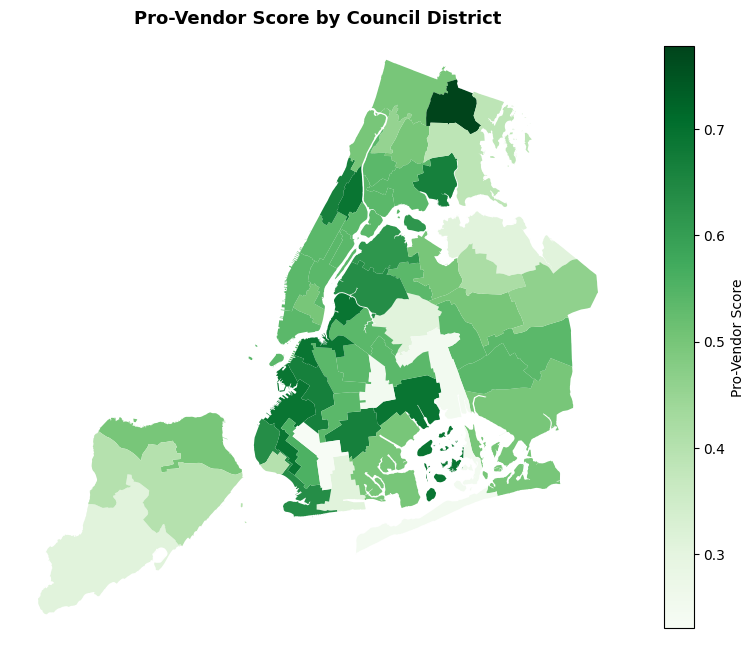

In [ ]:
# Plotting scores
fig, ax = plt.subplots(figsize=(8, 10))

district_scores.plot(
    ax=ax,
    column='score_overall', cmap="Greens",
    linewidth=0.1,
    legend=True, legend_kwds={'label': 'Pro-Vendor Score', 'shrink': 0.6},
    missing_kwds={'color': 'lightgrey', 'label': 'No data'}
)
ax.set_title('Pro-Vendor Score by Council District', fontweight='bold', fontsize=13)
ax.set_axis_off()

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/pro_vendor_score.png", dpi = 300, bbox_inches = "tight")
plt.show()

**Saving**

In [21]:
cc_analysis.to_file(f"{PRO_DATA_DIR}/cc_analysis.geojson", driver = "GeoJSON", index = False)